# Hybrid-Approach Projection Maps — SSP5-8.5
## Notebook 22

## 1. Imports

In [1]:
import warnings
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.feature import ShapelyFeature
from shapely.ops import unary_union
from shapely.geometry import box as sbox, Point
from pathlib import Path
from scipy.spatial import cKDTree
import pandas as pd

warnings.filterwarnings("ignore")
print("Libraries loaded.")

Libraries loaded.


## 2. Paths

In [2]:
COMMENTS_ROOT = Path(r"C:\Users\ASUS\Desktop\new.work.for.rainfall\comments")
OUTPUT_ROOT   = Path(r"C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\ssp5-8.5 output")

SHAPEFILE          = COMMENTS_ROOT / r"jordan.basins\surface.basins.for.jordan\Jo.shp"
RANKINGS_CSV       = COMMENTS_ROOT / r"validation\single.model\basin_model_rankings.csv"
RECOMMENDATION_CSV = COMMENTS_ROOT / r"validation\comparison\basin_approach_recommendation.csv"
ENS3_DIR           = OUTPUT_ROOT / "3 ensemble models"

SEASONAL_DIR = OUTPUT_ROOT / "projections" / "seasonal_means"
DIFF_DIR     = OUTPUT_ROOT / "projections" / "differences"
FIG_DIR      = OUTPUT_ROOT / "projections" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SYRIA_BASINS = {"YARMOUK (SYRIA)", "AZRAQ (SYRIA)", "AMMAN ZARQA (SYRIA)"}
PROJ         = ccrs.PlateCarree()
EXTENT       = [34.7, 39.5, 28.9, 33.8]

print("Paths configured.")

Paths configured.


## 3. Load Shapefile

In [3]:
gdf_all     = gpd.read_file(SHAPEFILE)
gdf_jordan  = gdf_all[~gdf_all["BASIN_NAME"].isin(SYRIA_BASINS)].copy().reset_index(drop=True)
jordan_national = unary_union(gdf_jordan.geometry)

full_bbox    = sbox(EXTENT[0]-2, EXTENT[2]-2, EXTENT[1]+2, EXTENT[3]+2)
outside_geom = full_bbox.difference(jordan_national)

print(f"Jordan basins: {len(gdf_jordan)}")

Jordan basins: 16


## 4. Load NC Data

In [4]:
def load_nc(path, var):
    ds   = xr.open_dataset(path)
    data = ds[var].values.astype(np.float32)
    lats = ds["lat"].values
    lons = ds["lon"].values
    ds.close()
    return data, lats, lons

ref_wet,       lats, lons = load_nc(SEASONAL_DIR / "hybrid_ssp585_ref_wet.nc",   "pr")
ref_dry,       _,    _    = load_nc(SEASONAL_DIR / "hybrid_ssp585_ref_dry.nc",   "pr")
near_wet_diff, _,    _    = load_nc(DIFF_DIR / "hybrid_ssp585_near_wet_diff.nc", "pr_diff")
near_dry_diff, _,    _    = load_nc(DIFF_DIR / "hybrid_ssp585_near_dry_diff.nc", "pr_diff")
mid_wet_diff,  _,    _    = load_nc(DIFF_DIR / "hybrid_ssp585_mid_wet_diff.nc",  "pr_diff")
mid_dry_diff,  _,    _    = load_nc(DIFF_DIR / "hybrid_ssp585_mid_dry_diff.nc",  "pr_diff")

CMAP_ABS = "YlGnBu"
CMAP_CHG = "BrBG"

# Colorbar limits set to cover actual data maxima/minima
panel_cfg = [
    # Row 0 — Wet season
    [(ref_wet,       CMAP_ABS,   0, 65, "Monthly Precipitation (mm/month)"),
     (near_wet_diff, CMAP_CHG, -10,  10, "Change in Monthly Precipitation (mm/month)"),
     (mid_wet_diff,  CMAP_CHG, -10,  10, "Change in Monthly Precipitation (mm/month)")],
    # Row 1 — Dry season
    [(ref_dry,       CMAP_ABS,   0,  10, "Monthly Precipitation (mm/month)"),
     (near_dry_diff, CMAP_CHG,  -10,   10, "Change in Monthly Precipitation (mm/month)"),
     (mid_dry_diff,  CMAP_CHG,  -10,   10, "Change in Monthly Precipitation (mm/month)")],
]

print(f"Grid: {len(lats)} lat × {len(lons)} lon")
print(f"Jordan valid cells: {int((~np.isnan(ref_wet)).sum())}")
print()
print("Data ranges per panel:")
for r, rl in enumerate(["Wet", "Dry"]):
    for c, cl in enumerate(["Ref", "Near-Δ", "Mid-Δ"]):
        v = panel_cfg[r][c][0]
        v = v[~np.isnan(v)]
        print(f"  {rl} {cl}: mean={v.mean():.2f}  max={v.max():.2f}  min={v.min():.2f}")

Grid: 85 lat × 75 lon
Jordan valid cells: 6375

Data ranges per panel:
  Wet Ref: mean=13.64  max=139.69  min=0.00
  Wet Near-Δ: mean=-0.21  max=7.74  min=-13.27
  Wet Mid-Δ: mean=0.23  max=9.50  min=-12.59
  Dry Ref: mean=2.19  max=23.37  min=0.00
  Dry Near-Δ: mean=0.08  max=3.89  min=-2.25
  Dry Mid-Δ: mean=0.33  max=2.22  min=-5.49


## 5. Per-Basin Statistics Table

In [5]:
jordan_data_mask   = ~np.isnan(near_wet_diff)
lon2d, lat2d       = np.meshgrid(lons, lats)
valid_ii, valid_jj = np.where(jordan_data_mask)

print(f"Total Jordan data cells: {jordan_data_mask.sum()}")
print("Building per-basin masks...")

basin_masks = {}
for _, brow in gdf_jordan.iterrows():
    bname = brow["BASIN_NAME"]
    poly  = brow.geometry
    mask  = np.zeros((len(lats), len(lons)), dtype=bool)
    for i, j in zip(valid_ii, valid_jj):
        if poly.contains(Point(lon2d[i, j], lat2d[i, j])):
            mask[i, j] = True
    basin_masks[bname] = mask
    print(f"  {bname:<35}: {int(mask.sum())} cells")

total = sum(m.sum() for m in basin_masks.values())
print(f"\nTotal assigned: {total}  (expected ~840)")

Total Jordan data cells: 6375
Building per-basin masks...
  HAMMAD                             : 176 cells
  YARMOUK (JORDAN)                   : 11 cells
  J.VALLEY-YARMOUK TRIANGLE          : 0 cells
  JORDAN VALLY (JORDAN)              : 5 cells
  N.R.S.W                            : 11 cells
  AZRAQ (JORDAN)                     : 113 cells
  AMMAN ZARQA (JORDAN)               : 33 cells
  S.R.S.W                            : 6 cells
  MUJIB                              : 61 cells
  D.S.R.S.W                          : 15 cells
  W. ARABA NORTH                     : 27 cells
  HASA                               : 22 cells
  JAFER                              : 116 cells
  WADI ARABA SOUTH                   : 55 cells
  QA DISI & SOUTHERN DESERT          : 36 cells
  SARHAN                             : 153 cells

Total assigned: 840  (expected ~840)


In [6]:
rankings = pd.read_csv(RANKINGS_CSV)
rankings.columns = [c.strip() for c in rankings.columns]
best_single_per_basin = (
    rankings.sort_values(["Basin", "Avg_Rank"]).groupby("Basin")["Model"].first().to_dict()
)

rec_df = pd.read_csv(RECOMMENDATION_CSV)
rec_df.columns = [c.strip() for c in rec_df.columns]
LABEL_TO_CODE = {"Best Single Model": "single", "3-Model Ensemble": "ens3"}
basin_approach = {
    row["Basin"]: LABEL_TO_CODE[row["Recommended_Approach"]]
    for _, row in rec_df.iterrows()
    if row["Recommended_Approach"] in LABEL_TO_CODE
}

gdf_jordan["cx"] = gdf_jordan.geometry.centroid.x
gdf_jordan["cy"] = gdf_jordan.geometry.centroid.y
ranked_rows   = [r for _, r in gdf_jordan.iterrows() if r["BASIN_NAME"] in basin_approach]
ranked_coords = np.array([[r["cy"], r["cx"]] for r in ranked_rows])
ranked_names  = [r["BASIN_NAME"] for r in ranked_rows]
kd_tree       = cKDTree(ranked_coords)
for _, row in gdf_jordan.iterrows():
    b = row["BASIN_NAME"]
    if b not in basin_approach:
        _, idx = kd_tree.query([row["cy"], row["cx"]])
        basin_approach[b] = basin_approach[ranked_names[idx]]

diff_grids = {
    ("near", "wet"): near_wet_diff,
    ("near", "dry"): near_dry_diff,
    ("mid",  "wet"): mid_wet_diff,
    ("mid",  "dry"): mid_dry_diff,
}
ref_grids_dict = {"wet": ref_wet, "dry": ref_dry}

PERIOD_LABEL = {"ref": "1995-2014 (Reference)", "near": "2021-2040 (Near-Future)", "mid": "2041-2060 (Mid-Future)"}
SEASON_LABEL = {"wet": "Wet Season (Oct-Mar)",  "dry": "Dry Season (Apr-Sep)"}

records = []
for bname, bmask in basin_masks.items():
    if not bmask.any():
        continue
    approach_label = "Best Single Model" if basin_approach.get(bname) == "single" else "3-Model Ensemble"

    # ── Reference period rows (absolute values) ──────────────────────────
    for season in ["wet", "dry"]:
        ref_mask = bmask & ~np.isnan(ref_grids_dict[season])
        ref_vals = ref_grids_dict[season][ref_mask]
        if ref_vals.size == 0:
            continue
        records.append({
            "Basin"                          : bname,
            "Approach"                       : approach_label,
            "Season"                         : SEASON_LABEL[season],
            "Period"                         : PERIOD_LABEL["ref"],
            "N_Grid_Cells"                   : int(ref_vals.size),
            "Precip_Mean_mm_per_month"       : round(float(ref_vals.mean()), 2),
            "Precip_Std_mm_per_month"        : round(float(ref_vals.std()),  2),
            "Precip_Max_mm_per_month"        : round(float(ref_vals.max()),  2),
            "Precip_Min_mm_per_month"        : round(float(ref_vals.min()),  2),
            "Change_Mean_mm_per_month"       : None,
            "Change_Std_mm_per_month"        : None,
            "Change_Max_mm_per_month"        : None,
            "Change_Min_mm_per_month"        : None,
            "Change_Pct_of_Reference"        : None,
        })

    # ── Future period rows (change values) ───────────────────────────────
    for (period, season), delta in diff_grids.items():
        cell_mask = bmask & ~np.isnan(delta)
        ref_mask  = bmask & ~np.isnan(ref_grids_dict[season])
        d_vals    = delta[cell_mask]
        ref_vals  = ref_grids_dict[season][ref_mask]
        if d_vals.size == 0:
            continue
        records.append({
            "Basin"                          : bname,
            "Approach"                       : approach_label,
            "Season"                         : SEASON_LABEL[season],
            "Period"                         : PERIOD_LABEL[period],
            "N_Grid_Cells"                   : int(d_vals.size),
            "Precip_Mean_mm_per_month"       : round(float(ref_vals.mean()), 2),
            "Precip_Std_mm_per_month"        : round(float(ref_vals.std()),  2),
            "Precip_Max_mm_per_month"        : round(float(ref_vals.max()),  2),
            "Precip_Min_mm_per_month"        : round(float(ref_vals.min()),  2),
            "Change_Mean_mm_per_month"       : round(float(d_vals.mean()),   2),
            "Change_Std_mm_per_month"        : round(float(d_vals.std()),    2),
            "Change_Max_mm_per_month"        : round(float(d_vals.max()),    2),
            "Change_Min_mm_per_month"        : round(float(d_vals.min()),    2),
            "Change_Pct_of_Reference"        : round(float(d_vals.mean() / ref_vals.mean() * 100)
                                                  if ref_vals.mean() != 0 else float("nan"), 1),
        })

df = pd.DataFrame(records)

check = df[(df["Season"] == "Wet Season (Oct-Mar)") & (df["Period"] == "2021-2040 (Near-Future)")]
print(f"Cell count verification (wet, near-future):")
print(f"  Total: {check['N_Grid_Cells'].sum()}  (expected ~840)")
print(check[["Basin", "Approach", "N_Grid_Cells"]].to_string(index=False))

out_csv = FIG_DIR / "basin_projected_changes_ssp585.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved → {out_csv}")

Cell count verification (wet, near-future):
  Total: 840  (expected ~840)
                    Basin          Approach  N_Grid_Cells
                   HAMMAD Best Single Model           176
         YARMOUK (JORDAN) Best Single Model            11
    JORDAN VALLY (JORDAN) Best Single Model             5
                  N.R.S.W  3-Model Ensemble            11
           AZRAQ (JORDAN)  3-Model Ensemble           113
     AMMAN ZARQA (JORDAN) Best Single Model            33
                  S.R.S.W Best Single Model             6
                    MUJIB Best Single Model            61
                D.S.R.S.W  3-Model Ensemble            15
           W. ARABA NORTH  3-Model Ensemble            27
                     HASA Best Single Model            22
                    JAFER Best Single Model           116
         WADI ARABA SOUTH  3-Model Ensemble            55
QA DISI & SOUTHERN DESERT Best Single Model            36
                   SARHAN  3-Model Ensemble           15

## 6. Build Figure

Saved → C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\ssp5-8.5 output\projections\figures\figure_hybrid_ssp585.png
Saved → C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\ssp5-8.5 output\projections\figures\figure_hybrid_ssp585.pdf


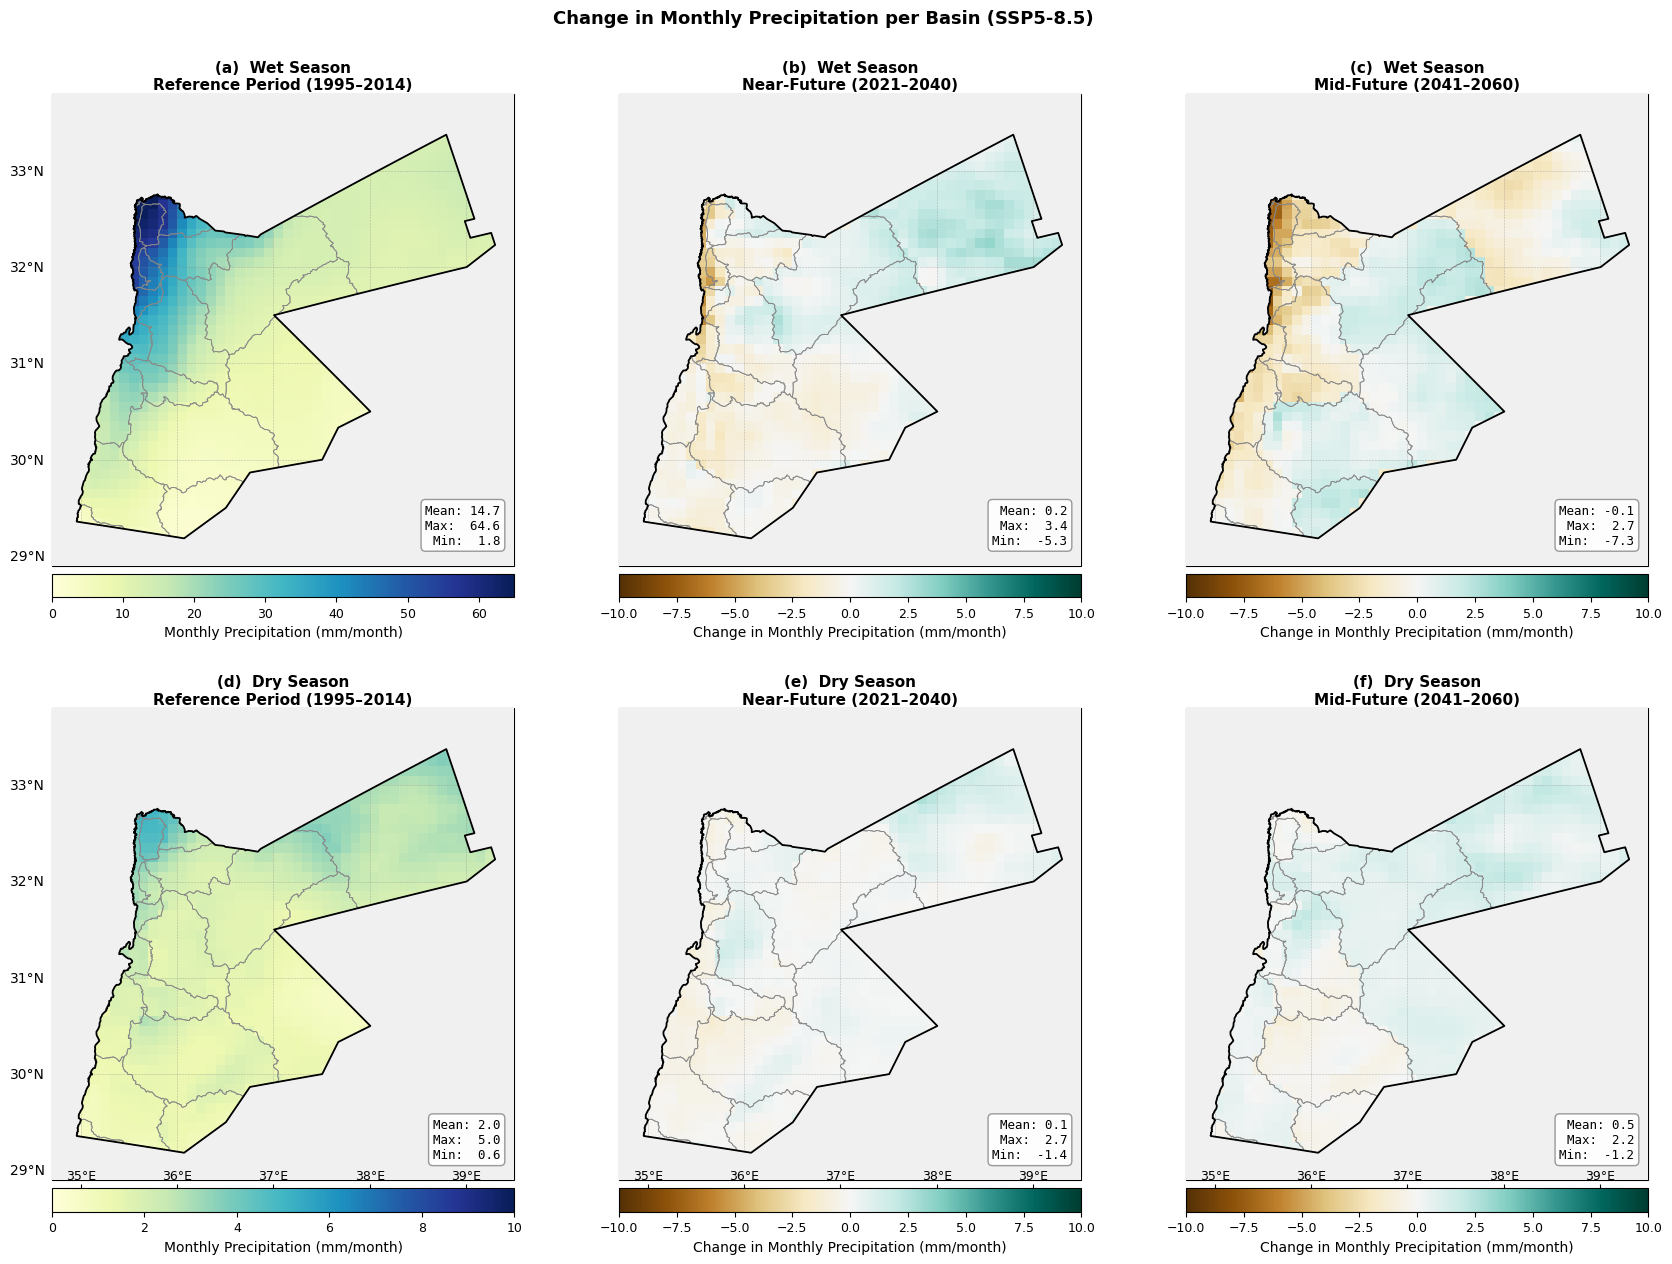

Done.


In [7]:
ROW_SEASON    = {0: "Wet Season",   1: "Dry Season"}
COL_PERIOD    = {
    0: ("Reference Period",  "(1995–2014)"),
    1: ("Near-Future",       "(2021–2040)"),
    2: ("Mid-Future",        "(2041–2060)"),
}
PANEL_LETTERS = [["(a)", "(b)", "(c)"], ["(d)", "(e)", "(f)"]]

# Tick definitions
EAST_TICKS  = [35, 36, 37, 38, 39]
NORTH_TICKS = [29, 30, 31, 32, 33]

def add_gridlines(ax, left=True):
    """Draw gridlines + North labels. East (°E) labels drawn via twiny on colorbar."""
    gl = ax.gridlines(draw_labels=False, linewidth=0.4,
                      color="grey", alpha=0.5, linestyle="--")
    gl.xlocator = mticker.FixedLocator(EAST_TICKS)
    gl.ylocator = mticker.FixedLocator(NORTH_TICKS)

    # North (latitude) labels — left column only, drawn in data coords
    if left:
        for lat_val in NORTH_TICKS:
            ax.text(-0.015, (lat_val - EXTENT[2]) / (EXTENT[3] - EXTENT[2]),
                    f"{lat_val}°N",
                    transform=ax.transAxes,
                    ha="right", va="center", fontsize=10, clip_on=False)



fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 13),
    subplot_kw={"projection": PROJ},
)
fig.subplots_adjust(left=0.05, right=0.98,
                    bottom=0.05, top=0.91,
                    wspace=0.05, hspace=0.22)

for row in range(2):
    for col in range(3):
        ax = axes[row, col]
        data, cmap, vmin, vmax, cbar_label = panel_cfg[row][col]

        ax.set_extent(EXTENT, crs=PROJ)

        pcm = ax.pcolormesh(
            lons, lats, np.ma.masked_invalid(data),
            cmap=cmap, vmin=vmin, vmax=vmax,
            transform=PROJ, zorder=1
        )

        ax.add_feature(
            ShapelyFeature([outside_geom], PROJ,
                           facecolor="#f0f0f0", edgecolor="none", zorder=3)
        )

        for _, brow in gdf_jordan.iterrows():
            ax.add_geometries([brow.geometry], crs=PROJ,
                              facecolor="none", edgecolor="#888888",
                              linewidth=0.6, zorder=4)

        ax.add_geometries([jordan_national], crs=PROJ,
                          facecolor="none", edgecolor="black",
                          linewidth=1.3, zorder=5)

        add_gridlines(ax, left=(col == 0))

        p0, p1 = COL_PERIOD[col]
        ax.set_title(
            f"{PANEL_LETTERS[row][col]}  {ROW_SEASON[row]}\n{p0} {p1}",
            fontsize=11, fontweight="bold", pad=3
        )

        # Stats from basin-masked cells only (matches CSV & visible map area)
        jordan_union_mask = np.zeros(data.shape, dtype=bool)
        for bmask in basin_masks.values():
            jordan_union_mask |= bmask
        v = data[jordan_union_mask & ~np.isnan(data)]
        txt = f"Mean: {v.mean():.1f}\nMax:  {v.max():.1f}\nMin:  {v.min():.1f}"
        ax.text(0.97, 0.04, txt,
                transform=ax.transAxes, fontsize=9,
                va="bottom", ha="right", family="monospace",
                bbox=dict(boxstyle="round,pad=0.35",
                          fc="white", alpha=0.88, ec="0.55"),
                zorder=8)

        divider = make_axes_locatable(ax)
        cax     = divider.append_axes("bottom", size="5%", pad=0.08,
                                      axes_class=plt.Axes)
        cb = fig.colorbar(pcm, cax=cax, orientation="horizontal")
        cb.set_label(cbar_label, fontsize=10)
        cb.ax.tick_params(labelsize=9)

        # °E labels as a secondary x-axis on TOP of the colorbar (bottom row only)
        if row == 1:
            tax = cax.twiny()
            # Map longitude range onto [0,1] in data space of the colorbar
            lon_min, lon_max = EXTENT[0], EXTENT[1]
            vmin_cb, vmax_cb = vmin, vmax
            # Convert each lon tick to colorbar data fraction
            lon_ticks_norm = [(l - lon_min) / (lon_max - lon_min) for l in EAST_TICKS]
            # Map to colorbar value space
            lon_ticks_cb   = [vmin_cb + n * (vmax_cb - vmin_cb) for n in lon_ticks_norm]
            tax.set_xlim(vmin_cb, vmax_cb)
            tax.set_xticks(lon_ticks_cb)
            tax.set_xticklabels([f"{v}°E" for v in EAST_TICKS], fontsize=9)
            tax.tick_params(axis="x", direction="out", length=3, pad=1,
                            top=True, bottom=False,
                            labeltop=True, labelbottom=False)
            # Hide the twin's spines so only the tick labels show
            for spine in tax.spines.values():
                spine.set_visible(False)


fig.suptitle("Change in Monthly Precipitation per Basin (SSP5-8.5)",
             fontsize=13, fontweight="bold", y=0.975)

for ext in ["png", "pdf"]:
    outfile = FIG_DIR / f"figure_hybrid_ssp585.{ext}"
    fig.savefig(outfile, dpi=600, bbox_inches="tight")
    print(f"Saved → {outfile}")

plt.show()
print("Done.")

## 7. Summary Pivot Table

In [8]:
# Pivot only on future-period rows (reference rows have no Change values)
df_future = df[df["Change_Mean_mm_per_month"].notna()].copy()
df_future["Approach_label"] = df_future["Approach"].map({"Best Single Model": "Best Single", "3-Model Ensemble": "3-Model Ens"})
pivot = df_future.pivot_table(
    index=["Basin", "Approach_label"],
    columns=["Season", "Period"],
    values="Change_Mean_mm_per_month"
).round(2)

print("Basin-average change in monthly precipitation (mm/month) — SSP5-8.5")
print("Positive = wetter | Negative = drier\n")
print(pivot.to_string())

Basin-average change in monthly precipitation (mm/month) — SSP5-8.5
Positive = wetter | Negative = drier

Season                                      Dry Season (Apr-Sep)                           Wet Season (Oct-Mar)                       
Period                                   2021-2040 (Near-Future) 2041-2060 (Mid-Future) 2021-2040 (Near-Future) 2041-2060 (Mid-Future)
Basin                     Approach_label                                                                                              
AMMAN ZARQA (JORDAN)      Best Single                       0.33                   0.80                   -0.38                  -1.62
AZRAQ (JORDAN)            3-Model Ens                      -0.08                   0.84                    0.85                   1.31
D.S.R.S.W                 3-Model Ens                      -0.66                   0.01                   -1.65                  -2.42
HAMMAD                    Best Single                       0.61                   1